# Подгружаем необходимые модули

In [328]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import tqdm

Проверяем, доступна ли gpu

In [329]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Класс с данными.

Атрибуты класса: минимальные и максимальные значения расчетной области, параметры задачи -- коэффициенты уравнения, кол-во точек.

В нем необходимо создать сетку, на которой будет рассчитываться задача и функцию **calculate_solution**, в которой будет создаваться атрибут **self.solution** с аналитическим решением:

# $u(x,t)=\exp{\left(\frac{-n^2\pi^2\alpha t}{m^2}\right) \sin \left( \frac{n\pi
			x}{m}\right)}.$

In [330]:
class Dataset:

    def __init__(self, alpha=0.3, # аргументы по умолчанию,
                 #которые будут равны этим значениям, если их не передать в функцию
                 xmin=0, tmin=0,
                 xmax=1, tmax=1,
                 Nx=100, Nt=50,
                 m=1, n=3):
        self.m, self.n = m, n
        self.alpha = alpha
        self.tmin = tmin
        self.xmin = xmin
        self.tmax = tmax
        self.xmax = xmax

        x1d=np.linspace(xmin, xmax, Nx)
        t1d=np.linspace(tmin, tmax, Nt)
        self.x, self.t = np.meshgrid(x1d, t1d)
        self.solution = self.calculate_solution(self.x, self.t)

    def calculate_solution(self, x, t):
        return np.exp((-(self.n**2)*((np.pi)**2)*self.alpha*t)/(self.m**2))*np.sin(self.n*np.pi*x/self.m) #аналитическое решение


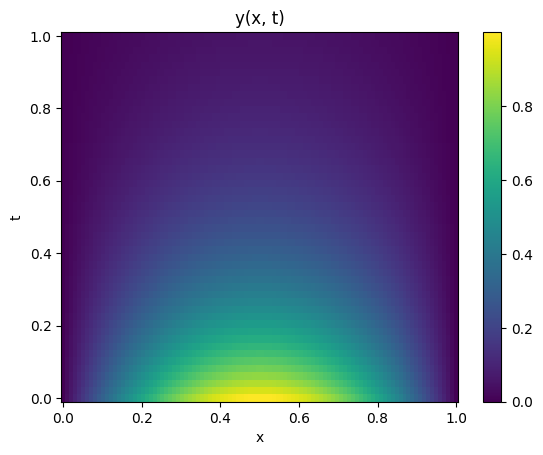

In [331]:
#создать датасет с m=1, n=1
data=Dataset(m = 1, n = 1)
#нарисовать график с аналитическим решением
plt.pcolormesh(data.x, data.t, data.solution)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('t')
plt.title('y(x, t)')

plt.show()

# Модель PINN

In [332]:
#класс с самой моделью

class SomeModel(nn.Module):
    def __init__(self,
                input_size = 2, #кол-во входных данных
                nnodes = 30, #кол-во нейронов на скрытом слое
                output_size = 1, #кол-во выходных данных
                nlayers = 20, #кол-во скрытых слоев
                 activation=nn.Tanh(), #функция активации
                 ):
        super().__init__()
        self.activation = activation
        self.nlayers = nlayers
        self.nnodes = nnodes

        self.dense0 = nn.Linear(input_size, nnodes)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(nnodes, nnodes) for _ in range(nlayers-1)
        ])

        self.output_layer = nn.Linear(nnodes, 1)
        self.apply(self._init_weights_xavier) # ИНИЦИАЛИЗАЦИЯ ВЕСОВ


    def _init_weights_xavier(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)


    def forward(self, x):
        # написать передачу по слоям
        if x.dtype == torch.float64:
            x = x.float()
        x = self.activation(self.dense0(x))

        for layer in self.hidden_layers:
          x = self.activation(layer(x))

        x = self.output_layer(x)
        x = self.activation(x)

        return x

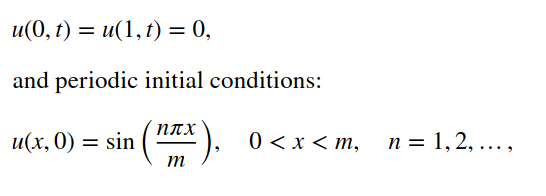

# Набор точек для граничного условия

Класс при инициализации принимает x, t -- входные точки.

*   Функция `flatten()` вытягивает входные массивы в столбцы.
*   Функция `torch.from_numpy` из numpy массива создает torch тензор.
*   `np.vstack` конкатинирует столбцы в один массив. Также необходимо, чтобы `grid`, т.е. то, что непосредственно подставляется в PINN, имела размер NxM, где N-кол-во точек, M-размерность задачи, в данном случае--2.
*   `torch.randperm` -- перемешивает индексы. Можно затем выбрать необходимое кол-во элементов.
*   `self.points.requires_grad` надо поставить `True`, чтобы рассчитывать производные

In [333]:
class Batch_bc:
    def __init__(self, x, t, values):
        x = x.flatten()
        t = t.flatten()
        values = values.flatten()
        self.grid = np.vstack((x, t)).T
        self.u = values.reshape(-1, 1)

    def generate_points(self, N):
        N = min(N, len(self.grid))
        indices = torch.randperm(len(self.grid))[:N]
        self.points = torch.from_numpy(self.grid[indices.numpy()]).float()
        self.values = torch.from_numpy(self.u[indices.numpy()]).float()
        self.points.requires_grad = True

# Набор точек во внутренней области

Класс при инициализации принимает x, t -- входные точки. Аналогично предыдущему классу. Но надо выбрать только внутреннюю область.

In [334]:
class Batch:
    def __init__(self, data: Dataset):
        x = data.x.flatten()
        t = data.t.flatten()
        self.grid = np.vstack((x, t)).T
        self.u = data.solution.reshape(-1, 1)   # ← читаем, не пишем в data.solution

    def generate_points(self, N):
        N = min(N, len(self.grid))
        indices = torch.randperm(len(self.grid))[:N]
        idx = indices.numpy()
        self.points = torch.from_numpy(self.grid[idx]).float()
        self.values = torch.from_numpy(self.u[idx]).float()
        self.points.requires_grad = True

# PDE -- функция, которая возвращает невязки от уравнений

Необходимо расчитывать производные через автоматическое дифференцирование:
```
gradu = torch.autograd.grad(u, grid,
                                torch.ones_like(u),
                                create_graph=True, \
                            retain_graph=True)[0] #x, t
```
* u -- переменная, от которой берется производная.


*  grid -- массив, по которому берется производная, т.е.:

d u / d grid

* Третий аргумент должен быть единичной матричей по размеру первого аргументы. Более подробное объяснение: https://discuss.pytorch.org/t/what-is-the-grad-outputs-kwarg-in-autograd-grad/94378/4

* retain_graph=True, чтобы граф вычислений сохранился и использовался затем при вызове Backward при обуении.

* create_graph=True, чтобы можно было далее посчитать производную более высокого порядка для этой переменной.







In [335]:
def PDE(u, grid, alpha):
    gradu = torch.autograd.grad(u, grid,
                                torch.ones_like(u),
                                create_graph=True,
                            retain_graph=True)[0]
    ux = gradu[:, 0:1]
    ut = gradu[:, 1:2]
    uxx = torch.autograd.grad(ux, grid,
                              torch.ones_like(ux),
                              create_graph = True,
                              retain_graph = True)[0][:, 0:1]

    #residuals -- невязка уравнения
    #(mse) между предсказанием и истинным значением.
    residuals=torch.mean((ut - alpha*uxx)**2)
    return residuals

# copyBCLoss -- функция для копирования граничного условия



*   out -- выход модели на сетке
*   loss -- так же, как и residuals -- СКЗ (mse) между предсказанием и истинным значением.



In [336]:
def copyBCLoss(model, grid, sol):
    out = model(grid)
    loss = torch.mean((sol - out)**2)
    return loss

# Параметры обучения

Необязательно делать в виде класса, но так удобнее передавать их в функцию одним классом, а не по отдельности. Плюс, это не глобальные переменные, разбросанные по всему коду.

In [337]:
class TrainParams:
    def __init__(self):
        self.alpha = 0.3 # параметр в уравнении диффузии
        self.numEpoch = 100 # кол-во эпох в цикле обучения
        self.numPoints = 1000 # размер батча для обучения во внутренней области
        self.numBCPoints = 200 # кол-во точек в батче для ГУ
        self.batch = None # сам батч, class Batch
        self.init_bc = None  # батч для ГУ слева, class Batch_bc
        self.right_bc = None # батч для ГУ справа, class Batch_bc
        self.left_bc = None # сам батч для НУ, class Batch_bc

# Функция residuals для расчета общего loss.

Loss здесь будет состоять из трех частей -- невязка от уравнений, отличие от ГУ и НУ.

Каждое слагаемое в Loss входит со своим весовым коэффициентом. Задайте коэффициент `k_bc=1e2`. Перед известными НУ и ГУ ставится всегда коэффициент больше, чтобы нейросеть быстрее их выучила.

In [338]:
def residuals(model, trp: TrainParams):
    grid = trp.batch.points
    out = model(grid)
    lossPDE = PDE(out, grid, trp.alpha)
    initBCLoss = copyBCLoss(model, trp.init_bc.points, trp.init_bc.values)
    rightBCLoss = copyBCLoss(model, trp.right_bc.points, trp.right_bc.values)
    leftBCLoss = copyBCLoss(model, trp.left_bc.points, trp.left_bc.values)
    k_bc = 1e2
    loss = lossPDE + k_bc*(initBCLoss + rightBCLoss + leftBCLoss)
    return loss

# Train

Сама функция обучения.

`pbar = tqdm.tqdm(range(trPs.numEpoch), desc='Training Progress')`

Это строка для вывода значений loss.

В цикле вам необходимо генерировать точки для внутренней области, ГУ, НУ.

In [339]:
def train(model, opt, scheduler, trPs: TrainParams):
    pbar = tqdm.tqdm(range(trPs.numEpoch), desc='Training Progress')
    hist_loss = []
    lrs = []
    for step in pbar:
        # сгенерировать точки для обучения
        trPs.batch.generate_points(trPs.numPoints)
        trPs.init_bc.generate_points(trPs.numBCPoints)
        trPs.right_bc.generate_points(trPs.numBCPoints)
        trPs.left_bc.generate_points(trPs.numBCPoints)
        def closure():
            #дописать функцию оптимизаторв
            opt.zero_grad()
            loss  = residuals(model, trPs)
            loss.backward()
            return loss

        current_loss = opt.step(closure)
        # для накопления шага планировщика
        lrs.append(opt.param_groups[0]["lr"])
        # обновление шага
        scheduler.step()

        # сохранение истории Loss
        hist_loss.append(current_loss.item())

        #логгирование
        if step % 2 == 0:
            pbar.set_description("Step: %d | Loss: %.10f" %
                                 (step, current_loss))

    return hist_loss, lrs

# Создание точек для обучения внутри области и для наччальных условий.

Визуализируйте график с помощью plt.scatter. В эту функцию передаются координаты точек, а окрасить их можно в цвет самих значений, это аргумент c (color).

Чтобы визуализировать данные, необходимо torch tensor вернуть в numpy массив на cpu:

`.detach().cpu().numpy()`

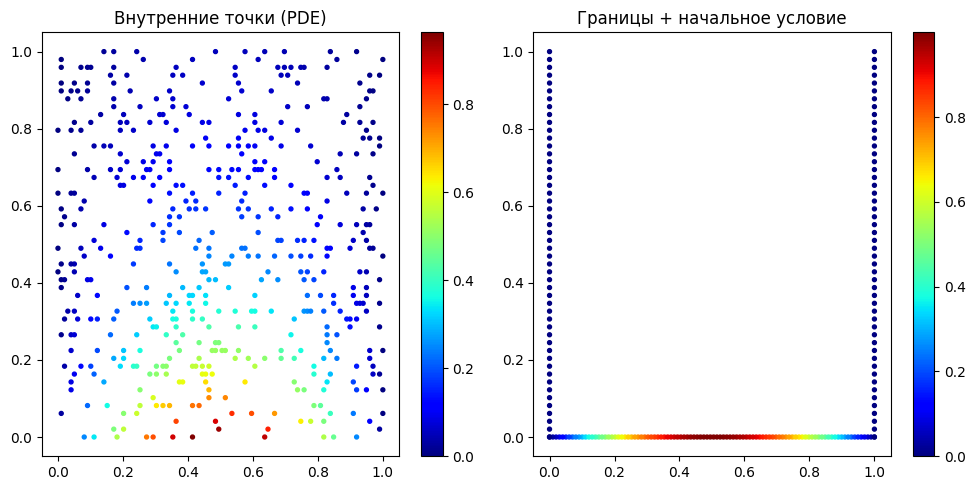

In [340]:
# --- параметры для удобства ---
L = data.xmax         # x ∈ [0, L]
N_plot = 500          # сколько внутренних точек рисовать
N_bc_plot = 100       # сколько BC/IC точек рисовать

# --- батч внутренних точек ---
train_batch = Batch(data)

# --- начальное условие: t = tmin, все x ---
initial_bc = Batch_bc(
    data.x[0, :].reshape(-1, 1),
    data.t[0, :].reshape(-1, 1),
    data.solution[0, :].reshape(-1, 1),
)

# --- граница слева: x = xmin, все t ---
left_bc = Batch_bc(
    data.x[:, 0].reshape(-1, 1),
    data.t[:, 0].reshape(-1, 1),
    data.solution[:, 0].reshape(-1, 1),
)

# --- граница справа: x = xmax, все t ---
right_bc = Batch_bc(
    data.x[:, -1].reshape(-1, 1),
    data.t[:, -1].reshape(-1, 1),
    data.solution[:, -1].reshape(-1, 1),
)

# --- генерация подвыборок ---
train_batch.generate_points(N_plot)
initial_bc.generate_points(N_bc_plot)
left_bc.generate_points(N_bc_plot)
right_bc.generate_points(N_bc_plot)

# --- графики ---
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

i = 0
pts = train_batch.points.detach().cpu().numpy()
vals = train_batch.values.detach().cpu().numpy().ravel()
f = ax[i].scatter(pts[:, 0], pts[:, 1], c=vals, cmap='jet', s=8)
ax[i].set_title('Внутренние точки (PDE)')
plt.colorbar(f, ax=ax[i])

i = 1
pts_bc = np.vstack([
    initial_bc.points.detach().cpu().numpy(),
    left_bc.points.detach().cpu().numpy(),
    right_bc.points.detach().cpu().numpy(),
])
vals_bc = np.concatenate([
    initial_bc.values.detach().cpu().numpy().ravel(),
    left_bc.values.detach().cpu().numpy().ravel(),
    right_bc.values.detach().cpu().numpy().ravel(),
])
f = ax[i].scatter(pts_bc[:, 0], pts_bc[:, 1], c=vals_bc, cmap='jet', s=8)
ax[i].set_title('Границы + начальное условие')
plt.colorbar(f, ax=ax[i])

plt.tight_layout()
plt.show()

# Задание параметров обучения.

* alpha=0.3
* Кол-во внутренних точек: 200
* Кол-во граничных точек: 100
* Кол-во эпох: 1000

In [341]:
trPs = TrainParams()
trPs.alpha       = data.alpha          # 0.3 — параметр уравнения диффузии
trPs.batch       = train_batch         # Batch(data) — внутренние точки
trPs.init_bc     = initial_bc          # Batch_bc — начальное условие (t = 0)
trPs.right_bc    = right_bc            # Batch_bc — граница справа (x = L)
trPs.left_bc     = left_bc             # Batch_bc — граница слева  (x = 0)
trPs.numPoints   = 200                # размер батча во внутренней области
trPs.numBCPoints = 100                 # размер батча для BC/IC
trPs.numEpoch    = 1000                # число эпох обучения

# Создание самой модели



*   кол-во нейронов: 10
*   кол-во скрытых слоев: 4
* функция активации: tanh
*   оптимизатор: SGD, lr=1
*   scheduler: LambdaLR, lambda1 -- 0.99**epoch
* lrs, hist_loss -- массивы для накопления значения шага обучения и Loss





In [342]:
model = SomeModel(nnodes = 10, nlayers = 4).to(device)

opt = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

lambda1 = lambda epoch: 0.99 ** epoch

scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda1)

lrs = []
hist_loss = []
hist_loss, lrs = train(model, opt, scheduler, trPs)

Step: 998 | Loss: 2.2314519882: 100%|██████████| 1000/1000 [00:05<00:00, 190.78it/s]


# Вывод графиков обучения и изменений шага обучения в логарифмическом масштабе

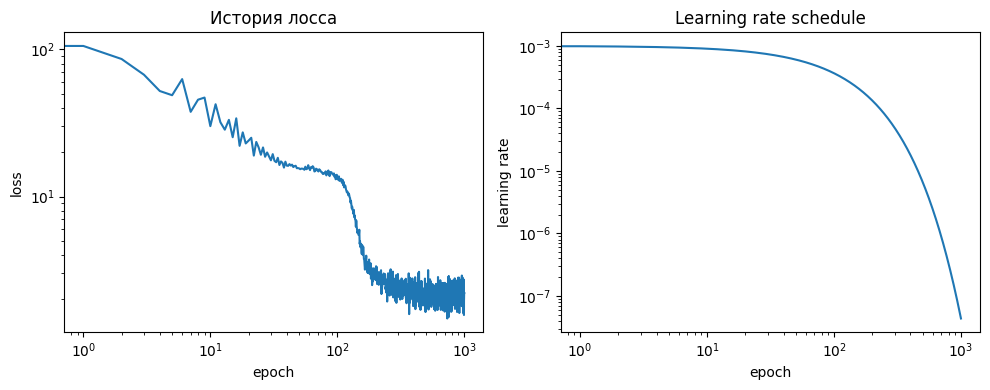

In [343]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

i = 0
ax[i].plot(hist_loss)
ax[i].set_xlabel('epoch')
ax[i].set_ylabel('loss')
ax[i].set_title('История лосса')
ax[i].set_xscale('log')
ax[i].set_yscale('log')

i = 1
ax[i].plot(lrs)
ax[i].set_xlabel('epoch')
ax[i].set_ylabel('learning rate')
ax[i].set_title('Learning rate schedule')
ax[i].set_xscale('log')
ax[i].set_yscale('log')

plt.tight_layout()
plt.show()

# Предсказания модели

* выведите предсказания модели на первоначальной квадратной сетке

* сделайте .detach().cpu().numpy().reshape, то есть превратите массив в массив первоначального размера

In [344]:
# 1) построить всю сетку (x, t) как тензор (N, 2)
grid_pred = torch.from_numpy(
    np.column_stack([data.x.flatten(), data.t.flatten()])
).float().to(device)

# 2) прогнать через модель, отвязать, вернуть в numpy и reshape к (Nt, Nx)
pred = model(grid_pred).detach().cpu().numpy().reshape(data.x.shape)

# Выведите точное решение, предсказанное значение, и их разность по модулю, нормированную на точное решение.

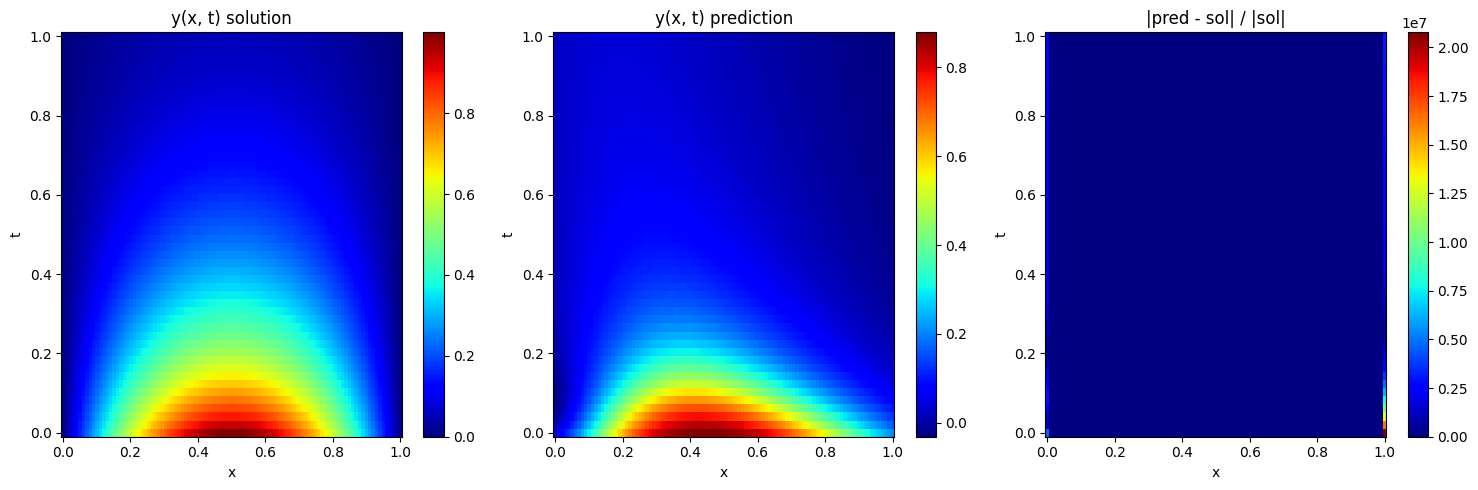

In [345]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# --- i = 0: точное (аналитическое) решение ---
i = 0
f = ax[i].pcolormesh(data.x, data.t, data.solution, cmap='jet', shading='auto')
plt.colorbar(f, ax=ax[i])
ax[i].set_xlabel('x')
ax[i].set_ylabel('t')
ax[i].set_title('y(x, t) solution')

# --- i = 1: предсказание модели ---
i = 1
f = ax[i].pcolormesh(data.x, data.t, pred, cmap='jet', shading='auto')
plt.colorbar(f, ax=ax[i])
ax[i].set_xlabel('x')
ax[i].set_ylabel('t')
ax[i].set_title('y(x, t) prediction')

# --- i = 2: |pred - sol| / |sol| (нормированная ошибка) ---
i = 2
err = np.abs(pred - data.solution) / (np.abs(data.solution) + 1e-8)
f = ax[i].pcolormesh(data.x, data.t, err, cmap='jet', shading='auto')
plt.colorbar(f, ax=ax[i])
ax[i].set_xlabel('x')
ax[i].set_ylabel('t')
ax[i].set_title('|pred - sol| / |sol|')

plt.tight_layout()
plt.show()